In [1]:
pip install kagglehub scipy scikit-learn pandas numpy matplotlib tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.io import wavfile
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración para mostrar los gráficos integrados en el cuaderno
%matplotlib inline

In [3]:
print("Descargando el dataset 'heartbeat-sounds' desde Kaggle...")
import kagglehub

# Descarga de la última versión disponible del dataset
dataset_path = kagglehub.dataset_download("kinguistics/heartbeat-sounds")
print(f"Dataset descargado correctamente en la ruta:\n{dataset_path}")

Descargando el dataset 'heartbeat-sounds' desde Kaggle...
Dataset descargado correctamente en la ruta:
C:\Users\joelr\.cache\kagglehub\datasets\kinguistics\heartbeat-sounds\versions\1


In [4]:
# Cargar el archivo de metadatos del set A
csv_file_path = os.path.join(dataset_path, "set_a.csv")
df_metadata = pd.read_csv(csv_file_path)

# Filtrar registros nulos y omitir la clase 'unclassified' (ruido de fondo)
df_metadata = df_metadata.dropna(subset=['label'])
df_metadata = df_metadata[df_metadata['label'] != 'unclassified']

print(f"Total de registros de audio válidos para el experimento: {len(df_metadata)}")
df_metadata[['fname', 'label']].head()

Total de registros de audio válidos para el experimento: 124


,fname,label
0,set_a/artifact__201012172012.wav,artifact
1,set_a/artifact__201105040918.wav,artifact
2,set_a/artifact__201105041959.wav,artifact
3,set_a/artifact__201105051017.wav,artifact
4,set_a/artifact__201105060108.wav,artifact


In [ ]:
print("Cargando archivos .wav y transformándolos en secuencias de longitud homogénea...")
X_raw_list = []
y_list = []

# Longitud temporal fija de 40,000 muestras para estandarizar las series
MAX_LENGTH = 40000 

for _, row in df_metadata.iterrows():
    audio_name = row['fname']
    # Corregir la ruta en caso de que el nombre del archivo contenga o no la subcarpeta
    if not audio_name.startswith("set_a/"):
        audio_path = os.path.join(dataset_path, "set_a", audio_name)
    else:
        audio_path = os.path.join(dataset_path, audio_name)
        
    if os.path.exists(audio_path):
        sample_rate, audio_sequence = wavfile.read(audio_path)
        
        # Convertir a canal mono si la señal viene en estéreo
        if len(audio_sequence.shape) > 1:
            audio_sequence = audio_sequence[:, 0]
            
        # Homogeneizar la longitud de la serie (truncar o rellenar con ceros si es más corta)
        if len(audio_sequence) > MAX_LENGTH:
            audio_sequence = audio_sequence[:MAX_LENGTH]
        else:
            audio_sequence = np.pad(audio_sequence, (0, MAX_LENGTH - len(audio_sequence)), 'constant')
            
        X_raw_list.append(audio_sequence)
        y_list.append(row['label'])

X_raw = np.array(X_raw_list)
y = np.array(y_list)

print(f"Dimensiones de la matriz de señales temporales puras: {X_raw.shape}")

Cargando archivos .wav y transformándolos en secuencias de longitud homogénea...
Dimensiones de la matriz de señales temporales puras: (124, 40000)


In [16]:
def extract_statistical_features(matrix_raw):
    features = []
    for row in matrix_raw:
        # Calcular las métricas solicitadas sobre cada serie de tiempo individual
        mean_val = np.mean(row)
        std_val = np.std(row) if np.std(row) > 0 else 1e-6
        skew_val = skew(row)
        kurt_val = kurtosis(row)
        min_val = np.min(row)
        max_val = np.max(row)
        energy = np.sum(row.astype(float)**2)  
        
        features.append([mean_val, std_val, skew_val, kurt_val, min_val, max_val, energy])
    return np.array(features)

print("Iniciando la extracción de características (Media, Desviación Estándar, Skewness, Kurtosis.)")
X_features = extract_statistical_features(X_raw)
print(f"Dimensiones de la nueva matriz de características reducida: {X_features.shape}\n")

# Nombres de las columnas correspondientes a cada métrica
feature_names = ['Media', 'Desviacion_Estandar', 'Skewness', 'Kurtosis', 'Minimo', 'Maximo', 'Energia']

# Creamos un DataFrame temporal
df_features_preview = pd.DataFrame(X_features, columns=feature_names)

# Si tienes las etiquetas a la mano, puedes agregarlas para enriquecer la vista (opcional)
if 'y' in locals() or 'y' in globals():
    df_features_preview['Clase_Target'] = y

print("VISTA PREVIA DE LAS PRIMERAS 5 INSTANCIAS EXTRAÍDAS")
# display() funciona de forma nativa en Jupyter para renderizar tablas HTML estilizadas
display(df_features_preview.head()) 

print("\n ESTADÍSTICO DE LAS CARACTERÍSTICAS EXTRAÍDAS")
display(df_features_preview.describe().round(4))

Iniciando la extracción de características (Media, Desviación Estándar, Skewness, Kurtosis.)
Dimensiones de la nueva matriz de características reducida: (124, 7)

VISTA PREVIA DE LAS PRIMERAS 5 INSTANCIAS EXTRAÍDAS


,Media,Desviacion_Estandar,Skewness,Kurtosis,Minimo,Maximo,Energia,Clase_Target
0,-0.069050,17.570197,-0.332504,90.335701,-284.0,234.0,1.234866e+07,artifact
1,-0.000250,2.058980,-0.001606,-0.052728,-8.0,8.0,1.695760e+05,artifact
2,0.011625,7.025143,0.018754,1.715198,-50.0,39.0,1.974111e+06,artifact
3,5.297200,747.251347,2.725815,284.128110,-24198.0,23988.0,2.233651e+10,artifact
4,-4.465725,403.897842,0.162685,8.688468,-3516.0,4393.0,6.526136e+09,artifact



 ESTADÍSTICO DE LAS CARACTERÍSTICAS EXTRAÍDAS


,Media,Desviacion_Estandar,Skewness,Kurtosis,Minimo,Maximo,Energia
count,124.0000,124.0000,124.0000,124.0000,124.0000,124.0000,1.240000e+02
mean,1.6560,2626.1978,0.0678,29.2934,-12075.8145,11713.4677,9.204128e+11
std,18.1871,4030.3939,1.1736,49.7799,10485.9323,10082.8208,2.558719e+12
min,-61.7829,2.0100,-3.9077,-1.5105,-32768.0000,8.0000,1.616010e+05
25%,-2.8141,317.5441,-0.3395,6.1430,-19783.0000,2532.5000,4.037348e+09
50%,0.0158,1068.6701,-0.0501,13.5003,-8922.5000,9457.5000,4.570869e+10
75%,4.9929,3285.6531,0.2323,34.0978,-2549.5000,18804.5000,4.318385e+11
max,107.0046,17847.2449,4.7942,381.8953,-8.0000,32766.0000,1.274097e+13


In [13]:
# División en entrenamiento (80%) y prueba (20%) de forma estratificada por el desbalance de clases
X_train_f, X_test_f, y_train, y_test = train_test_split(
    X_features, y, test_size=0.20, random_state=42, stratify=y
)

# Escalamiento Z-score para optimizar el rendimiento de los modelos lineales y de margen
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_f)
X_test_scaled = scaler.transform(X_test_f)

print(f"Instancias de entrenamiento: {X_train_scaled.shape[0]}")
print(f"Instancias de prueba: {X_test_scaled.shape[0]}")

Instancias de entrenamiento: 99
Instancias de prueba: 25


In [14]:
# Definición de los clasificadores sombríos tradicionales
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "SVM (Kernel RBF)": SVC(kernel='rbf', C=1.0, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

print("Entrenando y evaluando la suite de modelos shallow...")
for name, model in models.items():
    # Entrenamiento
    model.fit(X_train_scaled, y_train)
    # Predicción
    y_pred = model.predict(X_test_scaled)
    
    # Evaluación de métricas multiclase promedio 'macro'
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='macro', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='macro', zero_division=0)
    }

# Construcción de la tabla comparativa final
df_results = pd.DataFrame(results).T
print("\n=== TABLA COMPARATIVA DE RESULTADOS ===")
df_results.round(4)

Entrenando y evaluando la suite de modelos shallow...

=== TABLA COMPARATIVA DE RESULTADOS ===


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.44,0.2543,0.3705,0.2971
SVM (Kernel RBF),0.48,0.3611,0.4137,0.3839
Random Forest,0.48,0.4333,0.4330,0.3983
Gradient Boosting,0.52,0.4340,0.4435,0.4222


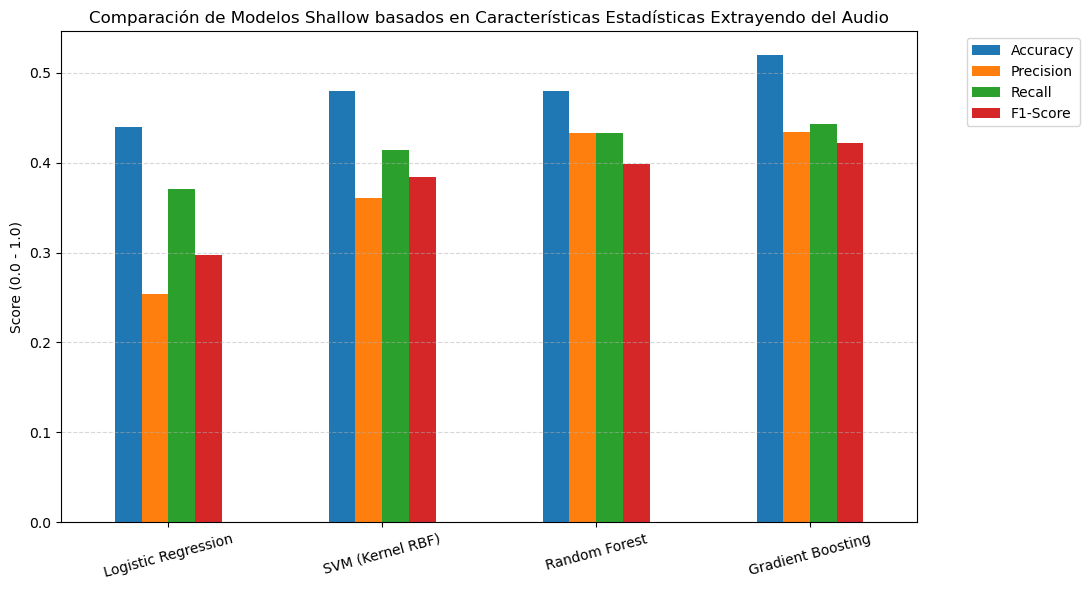

In [15]:
# Graficar las métricas obtenidas por cada modelo shallow
df_results.plot(kind='bar', figsize=(11, 6))
plt.title('Comparación de Modelos Shallow basados en Características Estadísticas Extrayendo del Audio', fontsize=12)
plt.ylabel('Score (0.0 - 1.0)', fontsize=10)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()